In [ ]:
import pandas as pd 
import torch 
import torchvision
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from torch import nn
import mlflow
from PIL import Image
import mlflow.pytorch

In [7]:
train_df = pd.read_csv('/home/lehoangvu/Project_AIDE1/notebooks/image_data_train.csv')
test_df = pd.read_csv('/home/lehoangvu/Project_AIDE1/notebooks/image_data_test.csv')

In [ ]:
class CUBDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        label = int(self.dataframe.iloc[idx]['class_idx'])
        image = Image.open(img_path).convert("RGB")
        image = image.crop(
            (
                self.dataframe.iloc[idx]['bbox_x'],
                self.dataframe.iloc[idx]['bbox_y'],
                self.dataframe.iloc[idx]['bbox_x'] + self.dataframe.iloc[idx]['bbox_w'],
                self.dataframe.iloc[idx]['bbox_y'] + self.dataframe.iloc[idx]['bbox_h']
            )
        )

        if self.transform:
            image = self.transform(image)

        return image, label

In [9]:
train_transform = transforms.Compose(
    [
        transforms.Resize((256, 256)),
        transforms.RandomCrop((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]
)

test_transform = transforms.Compose(
    [
        transforms.Resize((256, 256)),
        transforms.CenterCrop((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]
)

In [10]:
train_dataset = CUBDataset(train_df, transform=train_transform)
test_dataset = CUBDataset(test_df, transform=test_transform)
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=8, shuffle=True)

In [11]:
images, labels = next(iter(train_dataloader))
print(images.shape)
print(labels.shape)

torch.Size([8, 3, 224, 224])
torch.Size([8])


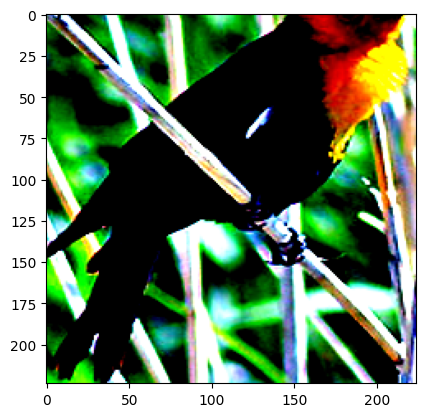

In [12]:
import matplotlib.pyplot as plt

tmp_image = images[2].permute(1, 2, 0).numpy()

plt.imshow(tmp_image)
plt.show()

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cpu


In [14]:
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT

model = torchvision.models.vit_b_16(weights=pretrained_vit_weights)

for param in model.parameters():
    param.requires_grad = False

model.heads.head = nn.Linear(in_features=768, out_features=50, bias=True)

epochs = 200
max_tolerance = 5
model = model.to(device)
optimizer = torch.optim.SGD(params=model.parameters(),
                             lr=0.03, momentum=0.9)
loss_fn = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

In [15]:
from tqdm import tqdm

def train(model, dataset):
    train_loss = 0
    train_acc = 0
    model.train()
    for batch, (images, labels) in tqdm(enumerate(dataset), total=len(dataset)):
        images = images.to(device)
        labels = labels.to(device)
        y_pred = model(images)
        loss = loss_fn(y_pred, labels)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        predicted_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (predicted_class == labels).sum().item()/len(predicted_class)

    train_loss = train_loss / len(dataset)
    train_acc = train_acc / len(dataset)
    return train_loss, train_acc

def test(model, dataset):
    test_acc = 0
    test_loss = 0
    model.eval()
    with torch.inference_mode():
        for batch, (images, labels) in tqdm(enumerate(dataset),total=len(dataset)):
            images = images.to(device)
            labels = labels.to(device)
            y_pred = model(images)
            loss = loss_fn(y_pred, labels)
            test_loss += loss.item()
            predicted_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
            test_acc += (predicted_class == labels).sum().item()/len(predicted_class)

    test_acc /= len(dataset)
    test_loss /= len(dataset)
    return test_loss, test_acc

# best_test_loss = float('inf')
# tolerance = 0
# for epoch in range(epochs):
#     print(f"Running epoch {epoch + 1}/{epochs}")
#     train_loss, train_acc = train(model, train_dataloader)
#     test_loss, test_acc = test(model, test_dataloader)
#     print(f"Train loss: {train_loss} | Train acc: {train_acc} | Test loss: {test_loss} | Test acc: {test_acc}")
#     if test_loss < best_test_loss:
#         best_test_loss = test_loss
#         print(f'Saving the best model at epoch {epoch + 1}')
#         torch.save(model.state_dict(), f'/home/lehoangvu/Project_AIDE1/models/model_{epoch + 1}.pth')
#         tolerance = 0
#     else:
#         tolerance += 1
#         print(f"Tolerance {tolerance}/{max_tolerance}")

#     if tolerance >= max_tolerance:
#         print("Model overfitting, stop training!!!")
#         break
#     scheduler.step()

In [16]:
best_epoch = 25
model = torchvision.models.vit_b_16(weights=pretrained_vit_weights)
model.heads.head = nn.Linear(in_features=768, out_features=50, bias=True)
model.load_state_dict(torch.load(f'/home/lehoangvu/Project_AIDE1/models/model_{best_epoch}.pth', map_location=device))

<All keys matched successfully>

In [40]:
test_loss, test_acc = test(model, test_dataloader)

100%|██████████| 174/174 [04:42<00:00,  1.62s/it]


In [42]:
test_acc

0.8436781609195403

In [17]:
from minio import Minio
import os
from dotenv import load_dotenv

load_dotenv()

minio_client = Minio(
    endpoint="localhost:9000",
    access_key=os.getenv("MINIO_ROOT_USER"),
    secret_key=os.getenv("MINIO_ROOT_PASSWORD"),
    secure=False
)
bucket_name = os.getenv("MINIO_BUCKET")

if not minio_client.bucket_exists(bucket_name):
    minio_client.make_bucket(bucket_name)
    print(f'Bucket {bucket_name} created.')
else:
    print(f'Bucket {bucket_name} already exists.')

Bucket mlflow already exists.


In [18]:
os.environ['AWS_ACCESS_KEY_ID'] = os.getenv('MINIO_ROOT_USER')
os.environ['AWS_SECRET_ACCESS_KEY'] = os.getenv('MINIO_ROOT_PASSWORD')
os.environ['MLFLOW_S3_ENDPOINT_URL'] = 'http://localhost:9000'

mlflow.set_tracking_uri("http://0.0.0.0:5000")
mlflow.set_experiment("main-experiment")

with mlflow.start_run():
    mlflow.pytorch.log_model(
        pytorch_model=model, 
        name="birds_classification_model",
        registered_model_name="BirdsClassificationModel"
    )
    mlflow.log_metric("test_accuracy", 84.36)
    mlflow.log_metric("test_loss", 0.5014)

2026/01/22 22:22:13 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Successfully registered model 'BirdsClassificationModel'.
2026/01/22 22:22:14 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: BirdsClassificationModel, version 1
Created version '1' of model 'BirdsClassificationModel'.


🏃 View run honorable-moose-623 at: http://0.0.0.0:5000/#/experiments/1/runs/5070ad21a1364ef58b341a941d1eeb42
🧪 View experiment at: http://0.0.0.0:5000/#/experiments/1


In [19]:
model = mlflow.pyfunc.load_model(
    model_uri="models:/BirdsClassificationModel/1"
)
model

/home/lehoangvu/Project_AIDE1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


mlflow.pyfunc.loaded_model:
  artifact_path: s3://mlflow/1/models/m-c17e476768c6492a8c57d093f475c5a9/artifacts
  flavor: mlflow.pytorch
  run_id: 5070ad21a1364ef58b341a941d1eeb42

In [20]:
with open('/home/lehoangvu/Project_AIDE1/data/CUB_200_2011/classes.txt', 'r') as f:
    classes = f.readlines()
    classes = [line.strip().split()[1].split('.')[-1] for line in classes]

class_2_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}
idx_2_class = {idx: cls_name for cls_name, idx in class_2_idx.items()}

In [ ]:
test_image = Image.open('/home/lehoangvu/Project_AIDE1/data/CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0001_796111.jpg').convert("RGB")
test_tensors = test_transform(test_image).unsqueeze(0)

predictions = model.predict(test_tensors.numpy())
predicted_class = predictions.argmax(axis=1)[0]
idx_2_class[predicted_class]

'Black_footed_Albatross'